### Install necessary libraries

In [2]:
!pip install nltk scikit-learn seaborn matplotlib

### Import libraries

In [3]:
import numpy as np
import pandas as pd
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

### Download NLTK stopwords

In [4]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Load dataset

In [5]:
dataset = pd.read_csv("/content/labeled_data.csv")

### Display dataset information

In [6]:
print(dataset.info())
print(dataset.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24783 entries, 0 to 24782
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Unnamed: 0          24783 non-null  int64 
 1   count               24783 non-null  int64 
 2   hate_speech         24783 non-null  int64 
 3   offensive_language  24783 non-null  int64 
 4   neither             24783 non-null  int64 
 5   class               24783 non-null  int64 
 6   tweet               24783 non-null  object
dtypes: int64(6), object(1)
memory usage: 1.3+ MB
None
         Unnamed: 0         count   hate_speech  offensive_language  \
count  24783.000000  24783.000000  24783.000000        24783.000000   
mean   12681.192027      3.243473      0.280515            2.413711   
std     7299.553863      0.883060      0.631851            1.399459   
min        0.000000      3.000000      0.000000            0.000000   
25%     6372.500000      3.000000      0.000000   

### Map labels

In [7]:
dataset["labels"] = dataset["class"].map({0: "Hate Speech", 1: "Offensive Language", 2: "No Hate or offensive language"})

### Create DataFrame with only relevant columns

In [8]:
data = dataset[["tweet", "labels"]]

### Define text cleaning function


In [9]:
def clean_data(text):
    text = str(text).lower()
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\[.*?\]', '', text)
    text = re.sub(r'<.*?>+', '', text)
    text = re.sub(r'[{}]'.format(re.escape(string.punctuation)), ' ', text)
    text = re.sub(r'\n', '', text)
    text = re.sub(r'\w*\d\w*', '', text)
    # Stop words removal
    words = [word for word in text.split(' ') if word not in stopwords]
    text = " ".join(words)
    # Stemming the text
    words = [stemmer.stem(word) for word in text.split(' ')]
    text = " ".join(words)
    return text

### Initialize stemmer and stopwords


In [10]:
stopwords = set(stopwords.words("english"))
stemmer = SnowballStemmer("english")

# Apply text cleaning


In [11]:
data["tweet"] = data["tweet"].apply(clean_data)

<ipython-input-11-44932d4fb622>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["tweet"] = data["tweet"].apply(clean_data)


### Prepare features and labels

In [12]:
x = np.array(data["tweet"])
y = np.array(data["labels"])

# Convert text to numerical features


In [13]:
cv = CountVectorizer()
x = cv.fit_transform(x)

### Split data into training and test sets

In [14]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.33, random_state=42)

### Build and train the model


In [21]:
dt = DecisionTreeClassifier()
dt.fit(x_train, y_train)
# Make Predictions
y_pred = dt.predict(x_test)
# Compute confusion matrix and accuracy
cn = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

### Display results

In [22]:
print("Confusion Matrix:")
print(cn)
print(f"Accuracy: {accuracy:.2f}")

Confusion Matrix:
[[ 172   51  242]
 [  26 1216  137]
 [ 292  183 5860]]
Accuracy: 0.89


### Plot confusion matrix

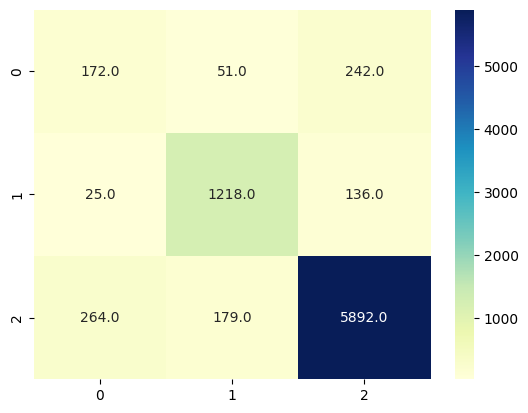

In [19]:
sns.heatmap(cn, annot=True, fmt=".1f", cmap="YlGnBu")
plt.show()

### Test with sample text

In [20]:
sample = "We should support each other in times of difficulty and work towards a better future for everyone."
sample_cleaned = clean_data(sample)
data1 = cv.transform([sample_cleaned]).toarray()
prediction = dt.predict(data1)
print(f"Sample text: '{sample}'")
print(f"Prediction: {prediction[0]}")

Sample text: 'We should support each other in times of difficulty and work towards a better future for everyone.'
Prediction: No Hate or offensive language
